# Building your own scenario

DisCoolPy scenarios are plain YAML. This notebook builds one from scratch for a
five-building campus, and along the way covers the two things that most often go
wrong: **how many pressure drops you are allowed to specify**, and **how many
heat duties**.

Both are counting problems with exact answers, and DisCoolPy checks them before
TESPy ever sees the network: because when TESPy rejects an over-determined
ladder it does so with a list of fifteen variable names and no indication of
which specification to remove.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

from discoolpy import (
    OCCUPANCY_ARCHETYPES,
    analyse_pressure_topology, build_system, flexibility_envelope,
    load_yaml_config, make_pipe_attrs, make_pipe_thermal, make_weather_and_load_profiles,
    run_configured_case, suggest_pressure_specification, validate_thermal_degrees_of_freedom,
)

CONFIG = Path("../configs/config_campus_five_buildings.yaml")
config = load_yaml_config(CONFIG)
print("archetypes available:", ", ".join(sorted(OCCUPANCY_ARCHETYPES)))
print("\ncampus:")
for b in config["buildings"]:
    print(f"  {b['label']:<20} {b['Q_design_W']/1e3:6.0f} kW   {b['archetype']}")

archetypes available: datacentre, hospital, hotel, office, residential, retail

campus:
  admin block             280 kW   office
  teaching hospital       520 kW   hospital
  student residence       310 kW   residential
  retail centre           240 kW   retail
  data hall               400 kW   datacentre


## 1. Counting pressure degrees of freedom

A branch is a hydraulic **ladder**. With `n` buildings there are `3n + 1`
elements that could fix a pressure drop (`n` supply pipes, `n` building legs,
`n` return pipes, one bypass) and `2n` unknown pressure nodes once the plant
loop anchors both ends. So exactly `2n` elements may be specified and `n + 1`
must be left free, one per independent loop.

Specify one too many and the problem is over-determined. One too few and it
floats. Neither is obvious by inspection once `n > 2`.

In [2]:
prs = [b.get("pr") for b in config["buildings"]]
bypass_fixed = config["branch"].get("bypass_dp", 0.0) is not None
report = analyse_pressure_topology(len(prs), prs, make_pipe_attrs(config), bypass_fixed)

print(f"buildings          : {report.n_buildings}")
print(f"elements           : {report.n_edges}   (= 3n + 1)")
print(f"unknown nodes      : {report.n_nodes}   (= 2n)")
print(f"independent loops  : {report.n_loops}   (= n + 1)")
print(f"specified          : {report.n_specified}")
print(f"\n{report.message()}\n")
print(pd.DataFrame([{"element": e.key, "from": e.node_a, "to": e.node_b,
                     "fixed by": e.spec} for e in report.edges]).to_string(index=False))

buildings          : 5
elements           : 16   (= 3n + 1)
unknown nodes      : 10   (= 2n)
independent loops  : 6   (= n + 1)
specified          : 10

Network pressure specification is consistent: 10 specified element(s) across branch for 10 unknown pressure node(s), 6 loop(s) left free.

   element from to             fixed by
  supply_1   S0 S1 darcy_group (L+D+ks)
  supply_2   S1 S2 darcy_group (L+D+ks)
  supply_3   S2 S3 darcy_group (L+D+ks)
  supply_4   S3 S4 darcy_group (L+D+ks)
  supply_5   S4 S5 darcy_group (L+D+ks)
building_1   S1 R1                 free
building_2   S2 R2                 free
building_3   S3 R3                 free
building_4   S4 R4                 free
building_5   S5 R5                 free
    bypass   S5 R5                 free
  return_1   R1 R0 darcy_group (L+D+ks)
  return_2   R2 R1 darcy_group (L+D+ks)
  return_3   R3 R2 darcy_group (L+D+ks)
  return_4   R4 R3 darcy_group (L+D+ks)
  return_5   R5 R4 darcy_group (L+D+ks)


In [3]:
# Deliberately break it the way the shipped scenarios were broken, and see what
# the checker says.
broken = [0.995 if b["label"] == "data hall" else b.get("pr") for b in config["buildings"]]
bad = analyse_pressure_topology(len(broken), broken, make_pipe_attrs(config), bypass_fixed)
print(bad.message())
print("\nA valid specification for a 5-building branch:")
for k, v in suggest_pressure_specification(5, bypass_fixed).items():
    print(f"  {k}: {v}")

Over-determined hydraulics: 1 redundant pressure specification(s). The network (branch) has 6 independent hydraulic loop(s), so exactly 10 of the 16 elements may fix a pressure drop; 11 do.
  - 'return_5' (darcy_group (L+D+ks)) closes a loop whose drop is already fixed by: building_5, supply_5, supply_4, supply_3, supply_2, supply_1, return_4, return_3, return_2, return_1
  Fix: remove the pressure specification from one element in each loop listed above (set the building's 'pr' to null, drop 'pr'/'L,D,ks' from the pipe, or set a terminal's 'dp' to null so its balancing valve reports the drop). Its pressure drop then becomes a solved output.

A valid specification for a 5-building branch:
  n_required: 10
  fixed: ['supply_1', 'supply_2', 'supply_3', 'supply_4', 'supply_5', 'return_1', 'return_2', 'return_3', 'return_4', 'return_5']
  free: ['bypass', 'building_1', 'building_2', 'building_3', 'building_4', 'building_5']
  note: Fix the listed elements (pipe 'pr' or 'L,D,ks'); leave the

Note which element it names. `data hall` is the last building, and the
end-of-line bypass spans the *same two nodes*, so fixing both is always
redundant, and it is the single easiest way to make a scenario unsolvable.

Here the bypass is left free (`bypass_dp: null`), which frees every
pipe to fix its own drop from geometry. The bypass valve then reports the
balancing drop, which is what a real end-of-line bypass valve does.

## 2. Counting energy degrees of freedom

The same logic applies to heat. Every pipe needs exactly one energy
specification, and the closed chilled-water loop needs exactly one *un*specified
energy variable to absorb the loop balance.

* `plant_control: supply_temperature`: the chiller duty is that free variable,
  so **every** pipe must be specified. This is required once anything gains heat.
* `plant_control: evaporator_duty`: the duty is asserted, so exactly one pipe
  must be left free instead.

The second arrangement is what the original scenarios used implicitly, with a
comment reading "Q not needed for the last return pipe". That pipe was a hidden
slack variable: any inconsistency between the asserted duty and the real loads
was dumped into it as a fictitious pipe heat duty, with nothing in the output to
flag it.

In [4]:
thermal = make_pipe_thermal(config)
keys = list(thermal)
specified = [k for k, v in thermal.items() if v.model != "adiabatic"]
validate_thermal_degrees_of_freedom(keys, specified, "supply_temperature")
print(f"{len(specified)}/{len(keys)} pipes carry a heat model, chiller duty is free -> consistent.\n")

try:
    validate_thermal_degrees_of_freedom(keys, specified[:-1], "supply_temperature")
except ValueError as exc:
    print("Removing one pipe's heat model:\n ", exc)

10/10 pipes carry a heat model, chiller duty is free -> consistent.

Removing one pipe's heat model:
  Chilled-water loop is under-specified: pipe(s) 'return_1' have no energy specification, and the chiller duty is already free under plant_control='supply_temperature'. Give every pipe a heat model (heat_model: adiabatic sets Q = 0).


In [5]:
# This campus mixes buried mains with an above-ground service-tunnel run.
rows = [{"pipe": k, "placement": v.geometry.get("placement"), "driven by": v.ambient_source,
         "L [m]": v.length_m, "D [m]": v.geometry.get("D"),
         "U' [W/(m·K)]": round(v.UA_per_m_W_mK, 3), "UA [W/K]": round(v.resolved_UA(), 1)}
        for k, v in thermal.items()]
frame = pd.DataFrame(rows)
print(frame.to_string(index=False))

surface = frame[frame.placement == "surface"]["U' [W/(m·K)]"].mean()
buried = frame[frame.placement == "buried"]["U' [W/(m·K)]"].mean()
print(f"\nMean U': buried {buried:.3f}, surface {surface:.3f} W/(m·K) "
      f"({surface/buried:.1f}x), and the surface run is driven by 41 °C air rather")
print("than 30 °C soil, so its actual heat gain per metre is higher still.")

    pipe placement driven by  L [m]  D [m]  U' [W/(m·K)]  UA [W/K]
supply_1    buried    ground  620.0  0.250         0.315     195.3
supply_2    buried    ground  380.0  0.225         0.297     113.0
supply_3   surface       air  260.0  0.200         0.371      96.4
supply_4    buried    ground  300.0  0.160         0.247      74.1
supply_5    buried    ground  340.0  0.125         0.217      73.7
return_5    buried    ground  340.0  0.125         0.217      73.7
return_4    buried    ground  300.0  0.160         0.247      74.1
return_3   surface       air  260.0  0.200         0.371      96.4
return_2    buried    ground  380.0  0.225         0.297     113.0
return_1    buried    ground  620.0  0.250         0.315     195.3

Mean U': buried 0.269, surface 0.371 W/(m·K) (1.4x), and the surface run is driven by 41 °C air rather
than 30 °C soil, so its actual heat gain per metre is higher still.


## 3. The profile generator scales with the scenario

Each building picks an occupancy archetype. The generator produces dry-bulb air,
**ground temperature** at the configured burial depth, and solar irradiance,
because pipes and envelopes are driven by different things.

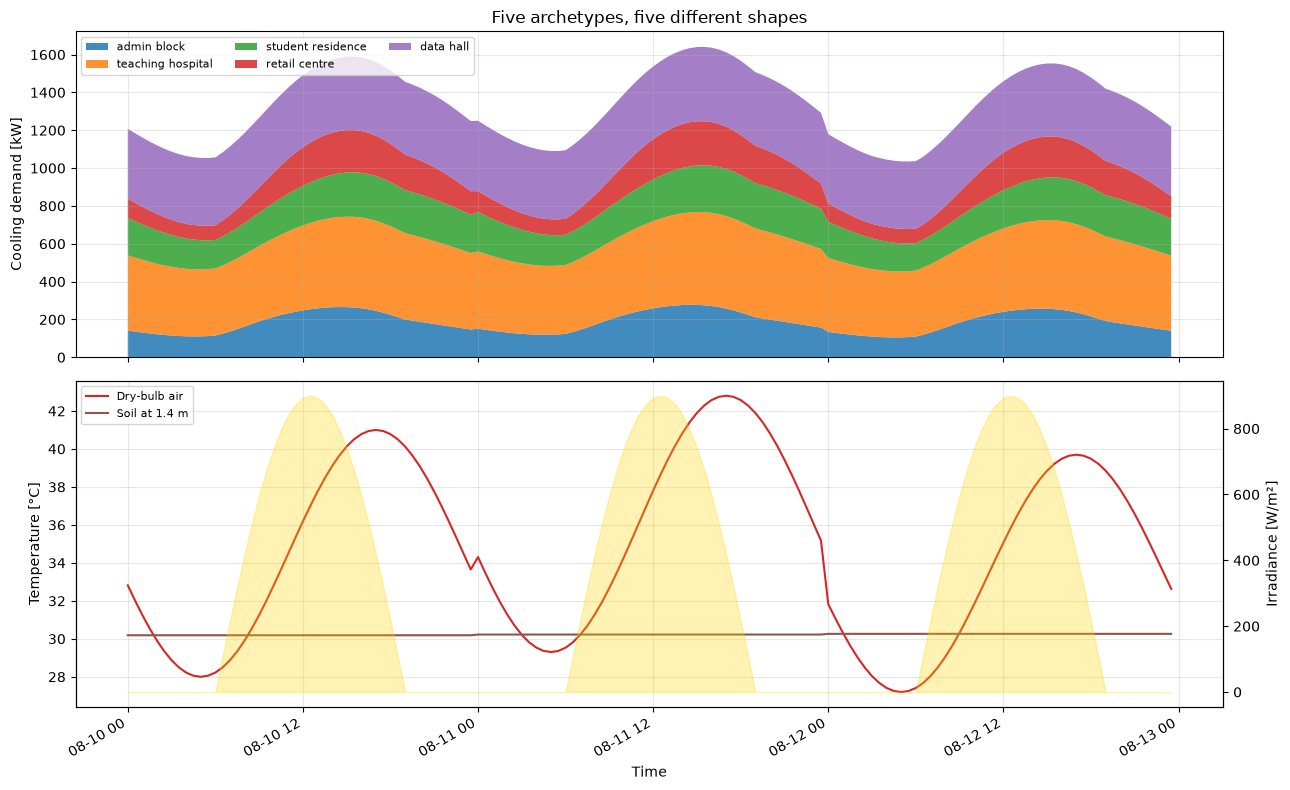

      ambient_temperature_degC  ground_temperature_degC
min                      27.20                    30.19
mean                     34.67                    30.22
max                      42.80                    30.26
std                       4.74                     0.03


In [6]:
profile = make_weather_and_load_profiles(config)
labels = [b["label"] for b in config["buildings"]]

fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
t = profile["timestamp"]
ax[0].stackplot(t, *[profile[f"{l}_Q_W"] / 1e3 for l in labels], labels=labels, alpha=0.85)
ax[0].set_ylabel("Cooling demand [kW]"); ax[0].legend(loc="upper left", fontsize=8, ncol=3)
ax[0].set_title("Five archetypes, five different shapes")
ax[0].grid(alpha=0.3)

ax[1].plot(t, profile.ambient_temperature_degC, color="tab:red", label="Dry-bulb air")
ax[1].plot(t, profile.ground_temperature_degC, color="tab:brown", label="Soil at 1.4 m")
ax2 = ax[1].twinx()
ax2.fill_between(t, profile.solar_irradiance_W_m2, color="gold", alpha=0.3, label="Irradiance")
ax2.set_ylabel("Irradiance [W/m²]")
ax[1].set_ylabel("Temperature [°C]"); ax[1].set_xlabel("Time")
ax[1].legend(loc="upper left", fontsize=8); ax[1].grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

print(profile[["ambient_temperature_degC", "ground_temperature_degC"]].describe().loc[
    ["min", "mean", "max", "std"]].round(2).to_string())

The data hall is flat (its load is process heat, barely weather-dependent), the
hospital nearly so, the retail centre swings hardest. Note the standard
deviations in the table: air swings by several kelvin over the horizon while the
soil is essentially constant. Driving buried pipes with air temperature would
invent a daily cycle in distribution losses that does not exist.

## 4. Solve it

A sensible-heat chilled-water store this time, rather than ice. Because it warms
as it discharges, its ambient heat gain *falls* with state of charge, something
an ice store cannot do, and one reason the two technologies behave differently
under the same weather.

In [7]:
system = build_system(config)
system.network.solve(mode="design", max_iter=300)
assert system.network.converged

q = system.chiller.solved_Q_evap_W
qb = sum(b.component.Q.val for b in system.buildings)
g = system.branch.heat_gain_report()
print(f"  buildings   : {qb/1e3:8.1f} kW")
print(f"  pipe gain   : {g['total_heat_gain_W']/1e3:8.1f} kW  ({100*g['total_heat_gain_W']/qb:.2f} %)")
print(f"  pump heat   : {system.branch.pump.P.val/1e3:8.1f} kW")
print(f"  plant duty  : {q/1e3:8.1f} kW   (residual "
      f"{q - qb - g['total_heat_gain_W'] - system.branch.pump.P.val:.4f} W)")
print()
print(f"  {system.branch.pressure_feasibility()['message']}")

store = system.storage
if store.is_stratified:
    # This scenario's store is a stratified tank, so its shell UA is the sum of
    # the layers' and its "medium temperature" is a profile, not a single number.
    tank = store.stratified
    print()
    print(f"  Stratified tank: {tank.volume_m3:.0f} m3 in {tank.layers} layers, "
          f"{tank.capacity_kWh:.0f} kWh")
    print(f"  Shell UA = {tank.describe()['shell_UA_W_K']:.0f} W/K")
    for soc in [1.0, 0.5, 0.0]:
        tank.reset(soc)
        gain = tank.step(1.0, 0.0, None, "idle", ambient_temperature_degC=41.0)
        print(f"    SOC {soc:.1f}: cold port {tank.cold_port_temperature_degC:5.1f} degC"
              f" -> {gain.ambient_heat_gain_W/1000:5.1f} kW gain at 41 degC ambient")
    tank.reset(store.initial_soc)
else:
    th = store.thermal
    print()
    print(f"  Store UA = {th.UA_W_K:.0f} W/K")
    for soc in [1.0, 0.5, 0.0]:
        print(f"    SOC {soc:.1f}: medium at {th.medium_temperature_degC(soc):5.1f} degC"
              f" -> {th.heat_gain_W(41.0, soc)/1000:5.1f} kW gain at 41 degC ambient")

  buildings   :   1750.0 kW
  pipe gain   :     24.3 kW  (1.39 %)
  pump heat   :     27.5 kW
  plant duty  :   1801.8 kW   (residual 0.0000 W)

  Branch pressure specification is feasible: every element drops pressure along the flow direction.

  Stratified tank: 425 m3 in 14 layers, 3204 kWh
  Shell UA = 75 W/K
    SOC 1.0: cold port   7.0 degC ->   2.6 kW gain at 41 degC ambient
    SOC 0.5: cold port   7.0 degC ->   2.3 kW gain at 41 degC ambient
    SOC 0.0: cold port  13.5 degC ->   2.1 kW gain at 41 degC ambient


In [8]:
without = run_configured_case(config, profile, "nb_campus_ref",  use_storage=False, progress=False)
with_st = run_configured_case(config, profile, "nb_campus_flex", use_storage=True,  progress=False)

from discoolpy import assess_flexibility
from IPython.display import Markdown, display
report = assess_flexibility(
    without, with_st, reference_name="no store", flexible_name="chilled-water store",
    tariff=config["economics"]["tariff"],
    carbon_intensity=config["economics"]["carbon_intensity_kg_kWh"],
)
display(Markdown(report.to_markdown()))

# Flexibility assessment: `chilled-water store` vs `no store`

Horizon resolution: 0.5 h.

## Headline

| Metric | Reference | Flexible | Change |
|---|---:|---:|---:|
| Peak compressor power [kW] | 434.9 | 381.1 | -53.8 (-12.4%) |
| Compressor energy [kWh] | 26142.6 | 26072.5 | -70.1 (-0.3%) |
| Load factor [-] | 0.835 | 0.950 | +0.115 |
| Mean COP [-] | 3.796 | 3.821 | +0.025 |
| Max ramp up [kW/h] | 17.7 | 16.8 | -0.9 |

## Where the flexibility went

| Quantity | Value |
|---|---:|
| Cooling charged into store [kWh] | 4820.6 |
| Cooling discharged from store [kWh] | 4694.5 |
| Store losses (ambient gain + standby) [kWh] | 139.4 |
| Net change in stored cooling over the horizon [kWh] | -92.9 |
| Thermal round-trip efficiency [-] | 0.955 |
| **Electric** round-trip efficiency [-] | 1.061 |
| COP while charging, vs the same hour in the reference [-] | +0.041 |
| Energy shifted out of the peak [kWh] | 921.6 |

## Economics

| Quantity | Reference | Flexible | Saving |
|---|---:|---:|---:|
| Electricity cost | 2875.69 | 2867.97 | +7.71 (+0.3%) |
| Emissions [kg CO2e] | 12548.4 | 12514.8 | +33.7 |

## Parasitic heat gains (reference)

| Source | Energy [kWh] | Share of building demand |
|---|---:|---:|
| Building demand served | 95860.4 | 100.0% |
| Distribution pipe gain | 1695.3 | 1.77% |
| Storage ambient gain | 0.0 | 0.00% |
| Pump heat | 1978.1 | 2.06% |
| **Plant cooling produced** | **99533.8** | 103.83% |

## Parasitic heat gains (flexible)

| Source | Energy [kWh] | Share of building demand |
|---|---:|---:|
| Building demand served | 95860.4 | 100.0% |
| Distribution pipe gain | 1695.3 | 1.77% |
| Storage ambient gain | 139.4 | 0.15% |
| Pump heat | 1978.1 | 2.06% |
| **Plant cooling produced** | **99659.9** | 103.96% |

Two things worth noticing in that table.

**The tariff here is flat** (0.11 per kWh, no peak block). With no price
difference between hours there is no arbitrage for the store to exploit, so the
extra kWh it costs shows up directly as a *higher* bill. Only a demand charge on
the peak kW could justify it. Contrast `heat_gains_and_flexibility.ipynb`, where
the same kind of store saves 7.4 % on a tariff with a hot-afternoon block.

**The electric round trip is below the thermal one.** Charging forces the plant
to produce water below the distribution setpoint, which depresses the
evaporating temperature. A model that shifted cooling at constant COP would
report only the thermal figure and overstate the case for the store.


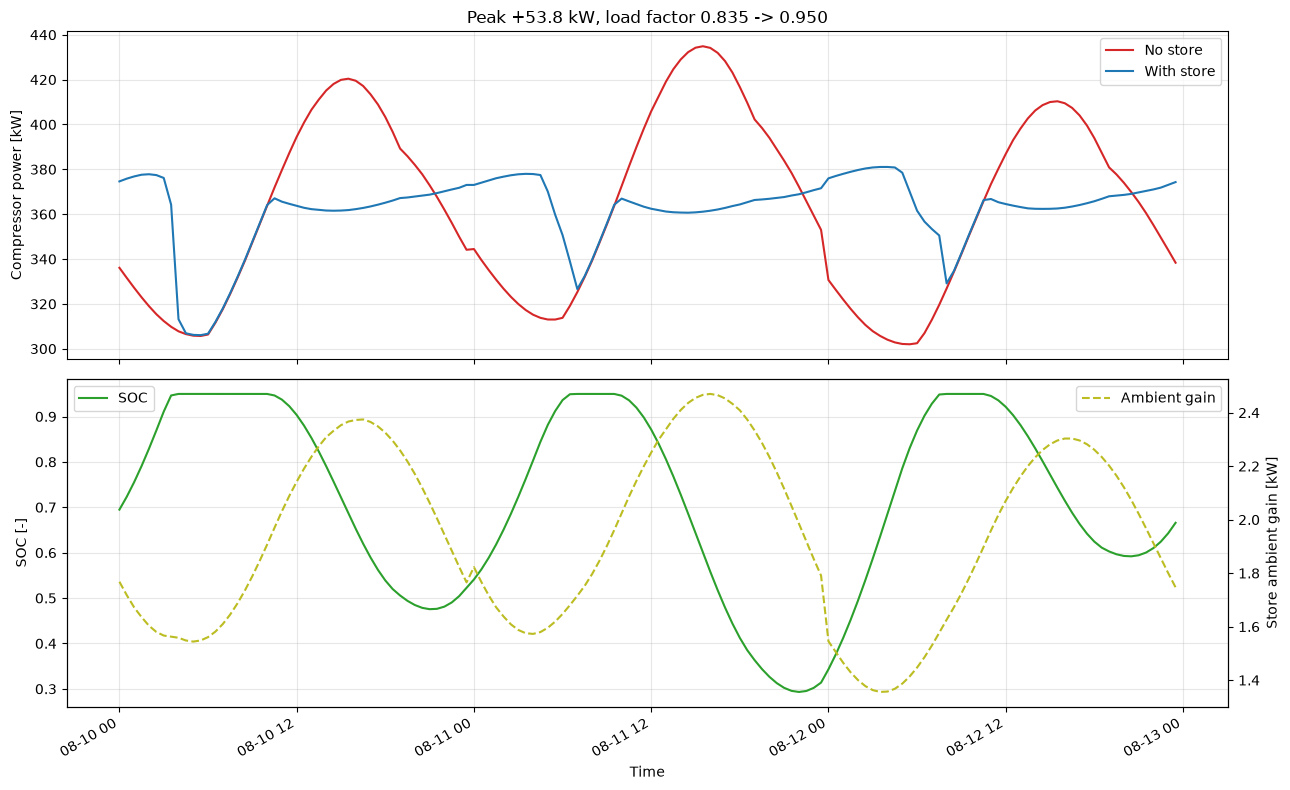

In [9]:
a = without.copy(); a["timestamp"] = pd.to_datetime(a["timestamp"])
b = with_st.copy(); b["timestamp"] = pd.to_datetime(b["timestamp"])
fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax[0].plot(a.timestamp, a.compressor_power_W / 1e3, color="tab:red", label="No store")
ax[0].plot(b.timestamp, b.compressor_power_W / 1e3, color="tab:blue", label="With store")
ax[0].set_ylabel("Compressor power [kW]"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title(f"Peak {report.peak_reduction_kW:+.1f} kW, load factor "
                f"{report.reference.load_factor:.3f} -> {report.flexible.load_factor:.3f}")
ax[1].plot(b.timestamp, b.storage_soc_after, color="tab:green", label="SOC")
axr = ax[1].twinx()
axr.plot(b.timestamp, b.storage_ambient_heat_gain_W / 1e3, color="tab:olive", ls="--",
         label="Ambient gain")
axr.set_ylabel("Store ambient gain [kW]")
ax[1].set_ylabel("SOC [-]"); ax[1].set_xlabel("Time"); ax[1].grid(alpha=0.3)
ax[1].legend(loc="upper left"); axr.legend(loc="upper right")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 5. How much flexibility does the system have right now?

`flexibility_envelope` reports the deliverable up/down cooling power at this
instant, respecting comfort bands, state of charge and power ratings, so the
numbers are biddable rather than nameplate.

In [10]:
env = flexibility_envelope(
    system.buildings, system.storage, dt_h=0.5,
    ambient_temperature_degC=41.0, solar_irradiance_W_m2=800.0,
)
print(f"  can absorb more cooling : {env['increase_W']/1e3:7.1f} kW "
      f"(store {env['storage_increase_W']/1e3:.1f}, buildings {env['building_increase_W']/1e3:.1f})")
print(f"  can shed cooling        : {env['decrease_W']/1e3:7.1f} kW "
      f"(store {env['storage_decrease_W']/1e3:.1f}, buildings {env['building_decrease_W']/1e3:.1f})")
print("\n  The buildings contribute nothing here because this scenario uses")
print("  load_model: profile. Give them an envelope and a thermal mass and they")
print("  would. See precooling_flexibility.ipynb.")

  can absorb more cooling :   420.0 kW (store 420.0, buildings 0.0)
  can shed cooling        :   420.0 kW (store 420.0, buildings 0.0)

  The buildings contribute nothing here because this scenario uses
  load_model: profile. Give them an envelope and a thermal mass and they
  would. See precooling_flexibility.ipynb.


## Checklist for a new scenario

1. **Pressure**: exactly `2n` elements fixed. The easiest convention is to fix every
   pipe from geometry, set `bypass_dp: null`, leave all building `pr: null`.
   Run `analyse_pressure_topology` before solving.
2. **Energy**: every pipe gets a `heat_model`. Use `plant_control:
   supply_temperature` whenever anything gains heat (DisCoolPy defaults to it).
3. **Pipe sizing**: aim for 1-2 m/s. Oversized pipes overstate heat gain and
   understate pumping simultaneously.
4. **Pump head**: check `branch.pressure_feasibility()`. If any element shows a
   pressure *rise*, the pump cannot serve the far end at design flow.
5. **Storage target**: set `target_chiller_load_kW` near the mean plant duty, not
   the peak. Too high and the store simply saturates and stops cycling.
6. **Run the design point first** with `examples/validate_scenario.py`
   before committing to a time series.